
# Introduction
This project builds a machine learning pipeline to predict used car prices using a dataset of 1,000 vehicles generated with an LLM and intentionally made messy to simulate real-world data challenges. The dataset spans 15 brands, model years 2005–2023, and four fuel types, and includes missing values across multiple columns. Rather than dropping or naively imputing the 115 missing engine size values, a dedicated Random Forest model was trained to predict them — preserving data integrity before the main modelling began. Two regression models were then built and compared: Linear Regression as an interpretable baseline and a tuned Random Forest as the primary model, using scikit-learn pipelines with proper preprocessing of both numerical and categorical features.

In [ ]:
#IMPORTING DEPENDENCIES 

In [250]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline # first fills missing values and then converts categories
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score 

In [23]:
#LOAD CSV
df = pd.read_csv("used_cars_dataset.csv")

In [27]:
#PREPROCESSING 

#printing first 5 rows    
df.head()

#at first glance 
#1. older model lesser price and newer model is pricier 
#2. there are null values 
#3. fuel_type, transmission, brand and model are the category type 

,brand,model,year,mileage,fuel_type,transmission,engine_size,horsepower,owner_count,price
0,Kia,Picanto,2010.0,246654.0,Petrol,Manual,2.0,163.0,3.0,1500.0
1,Honda,CR-V,2016.0,NaN,Diesel,Automatic,3.0,194.0,3.0,3590.0
2,Honda,Jazz,NaN,13158.0,Electric,Manual,NaN,212.0,3.0,21580.0
3,Volkswagen,Polo,2008.0,364471.0,Electric,Manual,NaN,200.0,2.0,1500.0
4,Mercedes-Benz,GLC,2014.0,185975.0,Diesel,Manual,1.6,139.0,3.0,7530.0


In [31]:
#check no of rows and columns 
df.shape


(1000, 10)

In [ ]:
#CHECKING FOR NULL VALUES AND DALING WITH IT 

In [56]:
# checking for number of null values 
df.isnull().sum()

# if <5% missing --> easy to handle (impute) 
# if 5-20% --> be careful of imputation 
# >30% --> consider dropping feature 


brand            29
model            24
year             31
mileage          32
fuel_type        23
transmission     35
engine_size     115
horsepower       25
owner_count      33
price             0
dtype: int64

In [78]:
#Since we have 115 null values, that's a lot, so instead of deleting or imputing, we will 
# PREDICT THE 115 ENGINE_SIZE to make our data consistent FOR BETTER PREDICTION 
df_known = df[df["engine_size"].notnull()]
df_unknown = df[df["engine_size"].isnull()] 


# X → brand, mileage, horsepower... we have to make sure we drop  engine_soze 
# y → engine_size
X = df_known.drop("engine_size", axis = 1)
y = df_known["engine_size"]

X_train , X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

In [248]:
# column-wise strategy to deal with null values 



# numerical columns - year, mileage, horsepower, owner count 
#use simple imputer and strategy = median 
num_imputer = ["year", "mileage", "horsepower", "owner_count"]

# categorical columns - brand, model, fuel_type, transmission 
# use simple imputer and the strategy = most_frequent 
cat_imputer = ["brand", "model", "fuel_type", "transmission"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median"))
])

# categorical columns - brand, model, fuel_type, transmission 
# use simple imputer and the strategy = most_frequent 

cat_pipeline = Pipeline ([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown= "ignore"))])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_imputer),
    ("cat", cat_pipeline, cat_imputer)
])
for col in num_imputer:
    df[col] = df[col].fillna(df[col].median())

for col in cat_imputer:
    df[col] = df[col].fillna(df[col].mode()[0])



In [74]:
# ADDING MODEL TO PREDICT engine size 
model = Pipeline([
    ("prep", preprocessor), 
    ("reg", RandomForestRegressor())
])

In [80]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [88]:
#Evaluating it 
pred = model.predict(X_test)

print(mean_absolute_error(y_test, pred))

0.44872316384180794


In [90]:
# df_unknown where the value is NaN
X_missing = df_unknown.drop("engine_size", axis = 1)
predicted_engine = model.predict(X_missing)
# what is happening here : "Based on these features, I think engine_size = 2.0"

df.loc[df["engine_size"].isnull(), "engine_size"] = predicted_engine

In [112]:

#cross checking if wre have any null values 
df.isnull().sum()

brand           0
model           0
year            0
mileage         0
fuel_type       0
transmission    0
engine_size     0
horsepower      0
owner_count     0
price           0
dtype: int64

In [114]:
df.head()

,brand,model,year,mileage,fuel_type,transmission,engine_size,horsepower,owner_count,price
0,Kia,Picanto,2010.0,246654.0,Petrol,Manual,2.000,163.0,3.0,1500.0
1,Honda,CR-V,2016.0,154943.5,Diesel,Automatic,3.000,194.0,3.0,3590.0
2,Honda,Jazz,2013.0,13158.0,Electric,Manual,3.140,212.0,3.0,21580.0
3,Volkswagen,Polo,2008.0,364471.0,Electric,Manual,2.809,200.0,2.0,1500.0
4,Mercedes-Benz,GLC,2014.0,185975.0,Diesel,Manual,1.600,139.0,3.0,7530.0


In [128]:
# categories 
#brands) 
print(df["brand"].value_counts())
print(" ")
print(df["model"].value_counts())
print(" ")
print(df["fuel_type"].value_counts())
print(" ")
print(df["transmission"].value_counts())


brand
BMW              111
Chevrolet         76
Lexus             71
Audi              71
Mercedes-Benz     70
Honda             68
Nissan            67
Jeep              66
Hyundai           65
Porsche           63
Kia               60
Volkswagen        56
Toyota            53
Ford              53
Mazda             50
Name: count, dtype: int64
 
model
5 Series     41
LS           16
Silverado    16
GLC          14
UX           14
             ..
Ranger        3
T-Roc         3
CX-9          3
Camry         3
Sentra        2
Name: count, Length: 120, dtype: int64
 
fuel_type
Petrol      556
Diesel      244
Hybrid      120
Electric     80
Name: count, dtype: int64
 
transmission
Automatic    675
Manual       325
Name: count, dtype: int64


## LINEAR REGRESSION 

In [135]:
# using OneHotEncoder 
categorical_col = ["brand", "model", "fuel_type", "transmission"] 

preprocessor = ColumnTransformer(
    transformers =[
        ("cat", OneHotEncoder(handle_unknown = "ignore"), categorical_col)
    ],
    remainder = "passthrough"
)
X_transformed = preprocessor.fit_transform(X)


In [155]:
# SPLIT DATA
X = df.drop("price", axis = 1)
y= df["price"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

#fit and transforming only on training data 
X_train_transformed = preprocessor.fit_transform(X_train)

#transform in test data 
X_test_transform = preprocessor.transform(X_test)

model = LinearRegression()
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transform)


In [205]:
# checking mean absoluter error 
error_check = mean_absolute_error(y_test, y_pred)
print("Mean square error value is", error_check,  " AED")



Mean square error value is 4437.102634954532  AED


On average, your predictions are off by about + -4.4k dhs 

In [203]:
#checking RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: ", rmse,  " AED")

RMSE:  5873.425277486478  AED


In [217]:
# r^2 value 
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6633303977077802


good/ descent value 

### IS THIS GOOD OR BAD 

- penalizes bigger error more
- some predictions are off by 6k dhs 

Depends on your price range :

IF YOUR CARS ARE :
- price range 20k - 40k dhs  - not the best
- price range 50k - 100k dhs - Pretty good
- price range 150k + dhs     - Very good 

## RANDOM FOREST

In [255]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Model
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_base = RandomForestRegressor(random_state=42)

# RandomizedSearchCV tries random combos — faster than GridSearch
# cv=5 means 5-fold cross validation is used during the search too
search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_grid,
    n_iter=20,            # tries 20 random combinations
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1             # uses all CPU cores, runs faster
)

search.fit(X_train_transformed, y_train)

print("Best parameters found:", search.best_params_)
print("Best CV R² score:     ", round(search.best_score_, 4))

# Use the best model going forward
best_rf = search.best_estimator_
y_prediction = best_rf.predict(X_test_transformed)



Best parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Best CV R² score:      0.8257


In [257]:


# We run CV on the full preprocessed data
X_full_transformed = preprocessor.fit_transform(X)

cv_scores = cross_val_score(
    best_rf,
    X_full_transformed,
    y,
    cv=5,
    scoring='r2'
)

print("\n--- 5-Fold Cross-Validation Results ---")
print("R² scores per fold:", [round(s, 4) for s in cv_scores])
print("Mean R²:  ", round(cv_scores.mean(), 4))
print("Std Dev:  ", round(cv_scores.std(), 4))
# A low std dev means your model is consistent, not just lucky on one split




--- 5-Fold Cross-Validation Results ---
R² scores per fold: [0.8794, 0.9403, 0.7409, 0.9343, 0.8536]
Mean R²:   0.8697
Std Dev:   0.0723


In [199]:
# mean absolute error 
error_check = mean_absolute_error(y_test, y_prediction)
print("Mean square error value is", error_check, " AED")


Mean square error value is 1697.7935  AED


In [201]:
rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
print("RMSE: ", rmse, " AED")

RMSE:  3901.1250077317445  AED


In [215]:
# r^2 value 
r2 = r2_score(y_test, y_prediction)
print("R2 Score:", r2)

R2 Score: 0.8514745953830197


In [ ]:

from sklearn.model_selection import cross_val_score

# We run CV on the full preprocessed data
X_full_transformed = preprocessor.fit_transform(X)

cv_scores = cross_val_score(
    best_rf,
    X_full_transformed,
    y,
    cv=5,
    scoring='r2'
)

print("\n--- 5-Fold Cross-Validation Results ---")
print("R² scores per fold:", [round(s, 4) for s in cv_scores])
print("Mean R²:  ", round(cv_scores.mean(), 4))
print("Std Dev:  ", round(cv_scores.std(), 4))
# A low std dev means your model is consistent, not just lucky on one split



very strong r^2 value 

### IS THIS GOOD OR BAD

## HUGE IMPROVEMENT ERROR REDUCED BY 60% AFTER USING RANDOM FOREST 

SO NOW : 
- Average prediction error is approximately 30k AED,
This is an excellent performance for a used car price prediction.

- Average prediction error is approximately 80k AED,
This is a strong performance for used car price prediction.

- Average prediction error is approximately 1.7k AED,
which is a strong performance for used car price prediction.

## WHY RANDOM FOREST PREFORMED BETTER 
SIMPLE BECAUSE 
- It captures non linear relationships 
- handles interaction like mileage + brand 
- year + model 
- doesnt assume staright line relationship (unlike Linear Regression) 

# VISUALIZATIONS 


### Price Distribution Histogram 

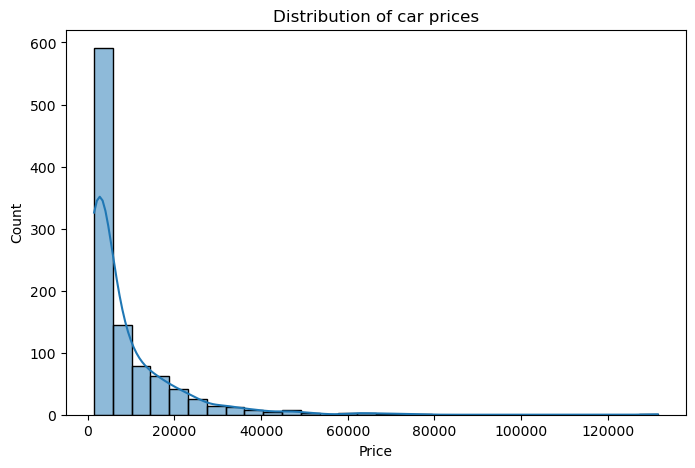

In [224]:

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins = 30, kde = True)
plt.title("Distribution of car prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Mileage vs prices 

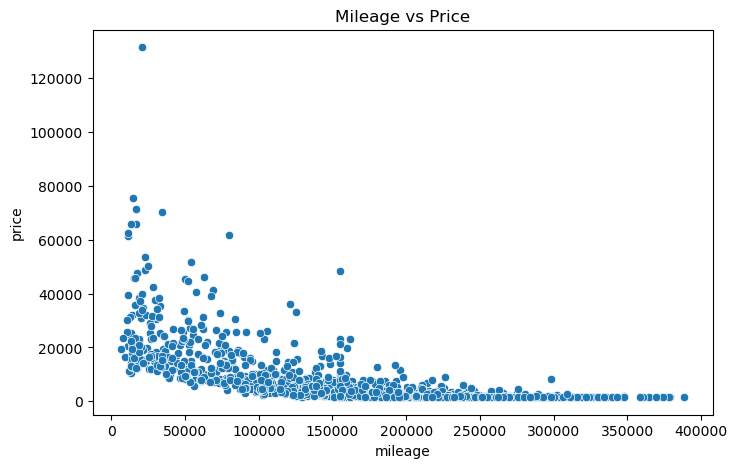

In [230]:
plt.figure(figsize = (8,5))
sns.scatterplot(x=df["mileage"], y=df["price"])
plt.title("Mileage vs Price")
plt.show()

### Brand vs average price 

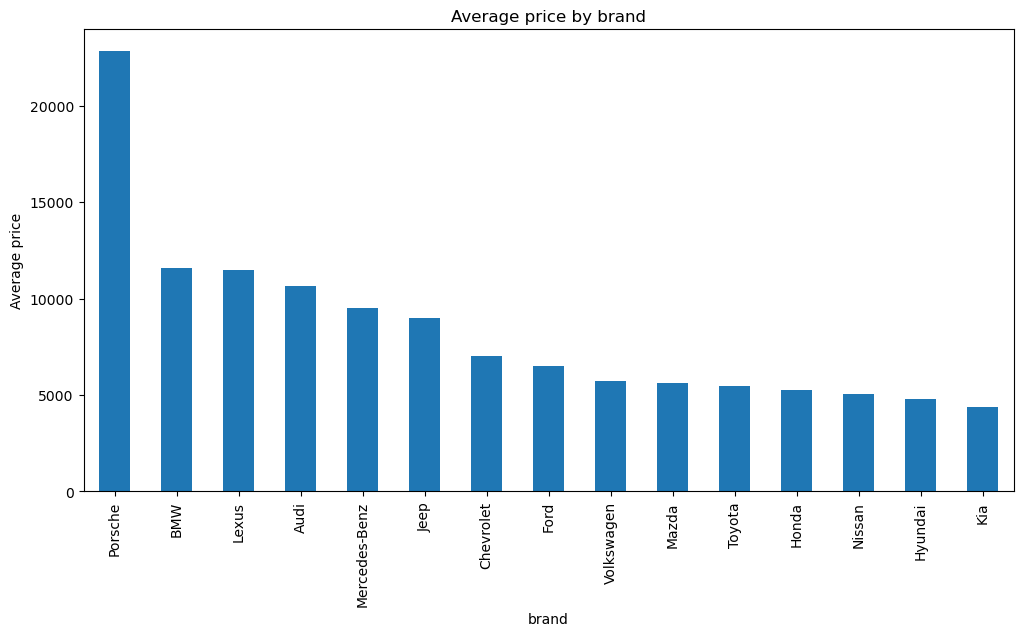

In [237]:
avg_price = df.groupby("brand")["price"].mean().sort_values(ascending = False)
plt.figure(figsize=(12,6))
avg_price.plot(kind = "bar")
plt.title("Average price by brand")
plt.ylabel("Average price")
plt.show()

### Correlation Heatmap 

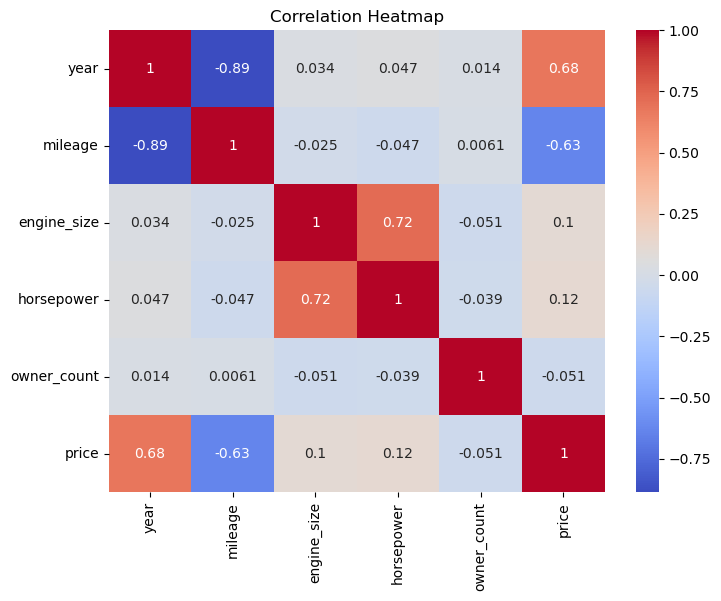

In [241]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

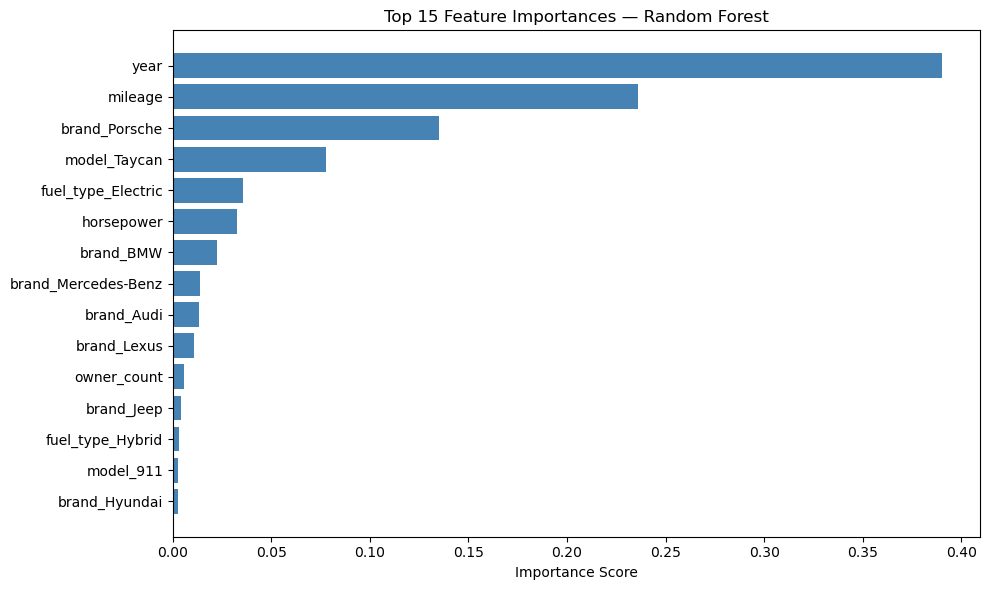


Top 5 most important features:
  1. year — 39.0%
  2. mileage — 23.61%
  3. brand_Porsche — 13.49%
  4. model_Taycan — 7.78%
  5. fuel_type_Electric — 3.58%


In [263]:
# ============================================================
# IMPROVEMENT 4 — FEATURE IMPORTANCE ANALYSIS
# Add this after cross-validation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Get feature names after one-hot encoding
cat_feature_names = list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_col)
)
num_feature_names = num_imputer   # ['year', 'mileage', 'horsepower', 'owner_count']

all_feature_names = num_feature_names + cat_feature_names

# Get importances from the tuned model
importances = best_rf.feature_importances_

# Sort and take top 15 for a clean chart
indices = np.argsort(importances)[::-1][:15]
top_features = [all_feature_names[i] for i in indices]
top_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_importances[::-1], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for i in range(5):
    print(f"  {i+1}. {top_features[i]} — {round(top_importances[i]*100, 2)}%")


# Summary
Linear Regression achieved an R² of 0.66 and a MAE of ~4,437 AED — a reasonable baseline but limited by its assumption of linear relationships. Switching to a Random Forest Regressor, tuned via RandomizedSearchCV across 20 hyperparameter combinations, reduced the MAE by 62% to ~1,698 AED and raised R² to 0.85. Five-fold cross-validation confirmed the model's consistency with a mean R² of 0.87, validating that the result was not a product of a lucky train-test split. Feature importance analysis revealed that year (39%) and mileage (23.6%) were the dominant pricing signals, with brand premiums such as Porsche contributing meaningfully — evidence that the model learned genuine pricing logic rather than surface-level patterns.